# Results: Adjusted R² on Test Split

This notebook summarizes model performance using **Adjusted R² on the test split** (other metrics are ignored).

1. Table of test Adjusted R² for every `(model, variant)`.
2. Top-5 `(model, variant)` by test Adjusted R², plus the baseline `(rf, cat)`.
3. Single bar plot comparing the top-5 against the baseline.


In [75]:
import pandas as pd
import matplotlib.pyplot as plt

BASELINE = ("rf", "cat")

df = pd.read_csv("metrics.csv")
df.head()

,timestamp,model,target,variant,split,metric,value
0,2026-06-06T18:41:09,mlp,price,cat,train,RMSE,220888.264406
1,2026-06-06T18:41:09,mlp,price,cat,train,MAE,147157.787057
2,2026-06-06T18:41:09,mlp,price,cat,train,MAPE,33.004414
3,2026-06-06T18:41:09,mlp,price,cat,train,R2,0.604110
4,2026-06-06T18:41:09,mlp,price,cat,train,Adjusted_R2,0.602406


In [77]:
# Keep only Adjusted R2 on the test split; one row per (model, variant).
mask = (df["split"] == "test") & (df["metric"] == "Adjusted_R2")
adj = (
    df.loc[mask, ["model", "variant", "value"]]
    .rename(columns={"value": "adjusted_r2_test"})
    .sort_values("adjusted_r2_test", ascending=False)
    .reset_index(drop=True)
)
adj

,model,variant,adjusted_r2_test
0,ensemble_rf,coord_only,0.755620
1,ensemble_mlp,tgt,0.746898
2,ensemble_mgbdt,tgt,0.744173
3,ensemble_mgbdt,coord_only,0.736508
4,mlp,tgt,0.733477
5,mgbdt,tgt,0.732663
6,ensemble_rf,tgt,0.732193
7,ensemble_mgbdt,tgt_only,0.728327
8,mgbdt,coord_only,0.725306
9,rf,coord_only,0.724477


## 2. Variant comparison for `rf` (cat vs coord_only vs tgt_only vs tgt)


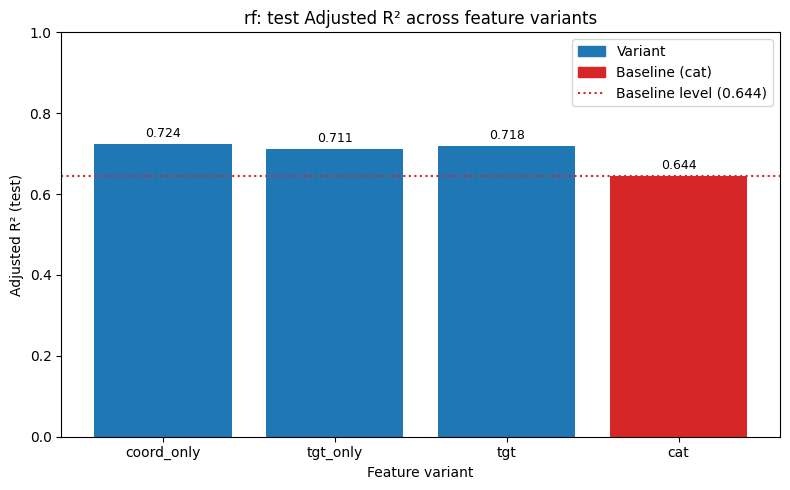

In [78]:
# Compare the rf model across feature variants, ordered from baseline to richest.
VARIANT_ORDER = ["coord_only", "tgt_only", "tgt", "cat"]

rf_variants = adj[adj["model"] == "rf"].copy()
rf_variants["variant"] = pd.Categorical(
    rf_variants["variant"], categories=VARIANT_ORDER, ordered=True
)
rf_variants = rf_variants.sort_values("variant").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))

# Baseline variant (cat) highlighted; others share a single colour.
colors = ["#d62728" if v == "cat" else "#1f77b4" for v in rf_variants["variant"]]
bars = ax.bar(
    rf_variants["variant"].astype(str), rf_variants["adjusted_r2_test"], color=colors
)

# Dotted reference line at the cat baseline level.
baseline_val = rf_variants.loc[
    rf_variants["variant"] == "cat", "adjusted_r2_test"
].iloc[0]
ax.axhline(baseline_val, color="#d62728", linestyle=":", linewidth=1.5)

ax.set_ylabel("Adjusted R² (test)")
ax.set_xlabel("Feature variant")
ax.set_title("rf: test Adjusted R² across feature variants")
ax.set_ylim(0, 1)

for bar, val in zip(bars, rf_variants["adjusted_r2_test"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#1f77b4", label="Variant"),
    plt.Rectangle((0, 0), 1, 1, color="#d62728", label="Baseline (cat)"),
    plt.Line2D(
        [0],
        [0],
        color="#d62728",
        linestyle=":",
        linewidth=1.5,
        label=f"Baseline level ({baseline_val:.3f})",
    ),
]
ax.legend(handles=legend_handles)

fig.tight_layout()
fig.savefig("rf_variant_comparison_test.png", dpi=150)
plt.show()

In [79]:
top5 = adj.head(5).copy()

# Ensure the baseline is present for comparison (added if not already in top-5).
baseline_row = adj[(adj["model"] == BASELINE[0]) & (adj["variant"] == BASELINE[1])]
is_baseline = (top5["model"] == BASELINE[0]) & (top5["variant"] == BASELINE[1])

if not is_baseline.any():
    plot_df = pd.concat([top5, baseline_row], ignore_index=True)
else:
    plot_df = top5.copy()

plot_df["is_baseline"] = (plot_df["model"] == BASELINE[0]) & (
    plot_df["variant"] == BASELINE[1]
)
plot_df["label"] = plot_df["model"] + " / " + plot_df["variant"]
plot_df = plot_df.sort_values("adjusted_r2_test", ascending=False).reset_index(
    drop=True
)
plot_df

,model,variant,adjusted_r2_test,is_baseline,label
0,ensemble_rf,coord_only,0.755620,False,ensemble_rf / coord_only
1,ensemble_mlp,tgt,0.746898,False,ensemble_mlp / tgt
2,ensemble_mgbdt,tgt,0.744173,False,ensemble_mgbdt / tgt
3,ensemble_mgbdt,coord_only,0.736508,False,ensemble_mgbdt / coord_only
4,mlp,tgt,0.733477,False,mlp / tgt
5,rf,cat,0.644489,True,rf / cat


## 3. Comparison plot


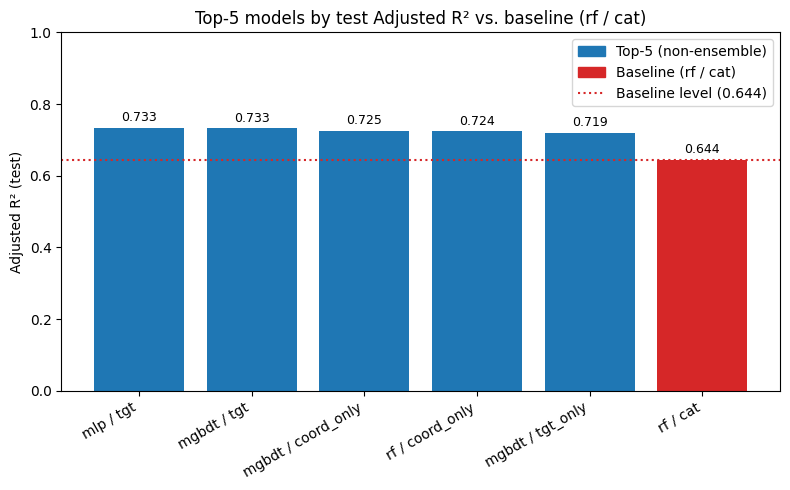

In [80]:
# Comparison restricted to non-ensemble models.
# Top-5 (model, variant) by test Adjusted R² after dropping any ensemble_* model,
# plus the baseline (rf / cat) for reference.
no_ens = adj[~adj["model"].str.startswith("ensemble")].copy()
top5_no_ens = no_ens.head(5).copy()

baseline_row_no_ens = no_ens[
    (no_ens["model"] == BASELINE[0]) & (no_ens["variant"] == BASELINE[1])
]
is_baseline_no_ens = (top5_no_ens["model"] == BASELINE[0]) & (
    top5_no_ens["variant"] == BASELINE[1]
)

if not is_baseline_no_ens.any():
    plot_df_no_ens = pd.concat([top5_no_ens, baseline_row_no_ens], ignore_index=True)
else:
    plot_df_no_ens = top5_no_ens.copy()

plot_df_no_ens["is_baseline"] = (plot_df_no_ens["model"] == BASELINE[0]) & (
    plot_df_no_ens["variant"] == BASELINE[1]
)
plot_df_no_ens["label"] = plot_df_no_ens["model"] + " / " + plot_df_no_ens["variant"]
plot_df_no_ens = plot_df_no_ens.sort_values(
    "adjusted_r2_test", ascending=False
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#d62728" if b else "#1f77b4" for b in plot_df_no_ens["is_baseline"]]
bars = ax.bar(plot_df_no_ens["label"], plot_df_no_ens["adjusted_r2_test"], color=colors)

# Horizontal reference line at the baseline level.
baseline_val = plot_df_no_ens.loc[
    plot_df_no_ens["is_baseline"], "adjusted_r2_test"
].iloc[0]
ax.axhline(
    baseline_val,
    color="#d62728",
    linestyle=":",
    linewidth=1.5,
    label=f"Baseline level ({baseline_val:.3f})",
)

ax.set_ylabel("Adjusted R² (test)")
ax.set_title("Top-5 models by test Adjusted R² vs. baseline (rf / cat)")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_ha("right")

for bar, val in zip(bars, plot_df_no_ens["adjusted_r2_test"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#1f77b4", label="Top-5 (non-ensemble)"),
    plt.Rectangle((0, 0), 1, 1, color="#d62728", label="Baseline (rf / cat)"),
    plt.Line2D(
        [0],
        [0],
        color="#d62728",
        linestyle=":",
        linewidth=1.5,
        label=f"Baseline level ({baseline_val:.3f})",
    ),
]
ax.legend(handles=legend_handles)

fig.tight_layout()
fig.savefig("top5_adjusted_r2_test_no_ensemble.png", dpi=150)
plt.show()

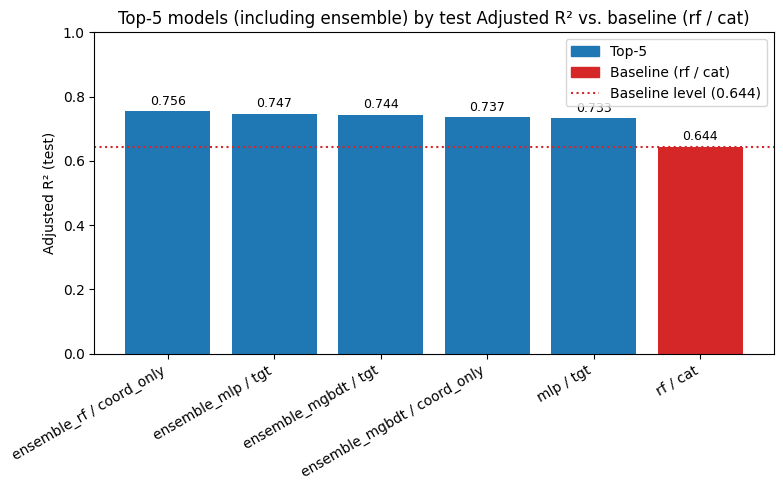

In [81]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#d62728" if b else "#1f77b4" for b in plot_df["is_baseline"]]
bars = ax.bar(plot_df["label"], plot_df["adjusted_r2_test"], color=colors)

# Horizontal reference line at the baseline level.
baseline_val = plot_df.loc[plot_df["is_baseline"], "adjusted_r2_test"].iloc[0]
ax.axhline(
    baseline_val,
    color="#d62728",
    linestyle=":",
    linewidth=1.5,
    label=f"Baseline level ({baseline_val:.3f})",
)

ax.set_ylabel("Adjusted R² (test)")
ax.set_title(
    "Top-5 models (including ensemble) by test Adjusted R² vs. baseline (rf / cat)"
)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_ha("right")

for bar, val in zip(bars, plot_df["adjusted_r2_test"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#1f77b4", label="Top-5"),
    plt.Rectangle((0, 0), 1, 1, color="#d62728", label="Baseline (rf / cat)"),
    plt.Line2D(
        [0],
        [0],
        color="#d62728",
        linestyle=":",
        linewidth=1.5,
        label=f"Baseline level ({baseline_val:.3f})",
    ),
]
ax.legend(handles=legend_handles)

fig.tight_layout()
fig.savefig("top5_adjusted_r2_test.png", dpi=150)
plt.show()